# Project 2 — Image Compression using Singular Value Decomposition

This project investigates the use of truncated Singular Value Decomposition (SVD)
for image compression. Three images with different structural characteristics are
compared: a smooth sky image, a highly detailed foliage image, and a building image
containing a mixture of smooth regions and sharp edges.

The analysis evaluates the trade-off between reconstruction quality and storage,
and compares three methods for selecting the truncation rank k.

In [78]:
pip install numpy pandas matplotlib pillow scikit-image


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [79]:
#Import the libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [80]:
#Set the random seed
seed = 42
rng = np.random.default_rng(seed)

In [81]:
#Setup the images path

IMAGE_FOLDER = Path("images")

image_paths = {
    "Smooth - Sky" : IMAGE_FOLDER / "smooth.jpg",
    "Detailed - Foliage" : IMAGE_FOLDER / "detailed.jpg",
    "Mixed - Buildings" : IMAGE_FOLDER / "mixed.jpg"
}

In [82]:
#Create the greyscale conversion function
def load_grayscale(path, max_size=750):
    image = Image.open(path).convert("RGB")

    # Resize only if the image is larger than max_size
    image.thumbnail((max_size, max_size))

    image = np.array(image, dtype=float)

    image = image / 255.0

    gray = (
        0.2126 * image[:, :, 0]
        + 0.7152 * image[:, :, 1]
        + 0.0722 * image[:, :, 2]
    )

    return gray

In [83]:
#Load all three images
images = {}

for name, path in image_paths.items():
    images[name] = load_grayscale(path)

In [84]:
#Check that the images loaded correctly

for name,image in images.items():
    print(name)
    print("Shape: ", image.shape)
    print("Data Type: ", image.dtype)

Smooth - Sky
Shape:  (493, 740)
Data Type:  float64
Detailed - Foliage
Shape:  (450, 675)
Data Type:  float64
Mixed - Buildings
Shape:  (750, 631)
Data Type:  float64


In [85]:
#Report the number of values in each image

image_information = []

for name, image in images.items():

    m, n = image.shape

    image_information.append(
        {
            "Image": name,
            "Height (m)": m,
            "Width (n)" : n,
            "Numbers in original image" : m * n
        }
    )

image_info_df = pd.DataFrame(image_information)

image_info_df

,Image,Height (m),Width (n),Numbers in original image
0,Smooth - Sky,493,740,364820
1,Detailed - Foliage,450,675,303750
2,Mixed - Buildings,750,631,473250


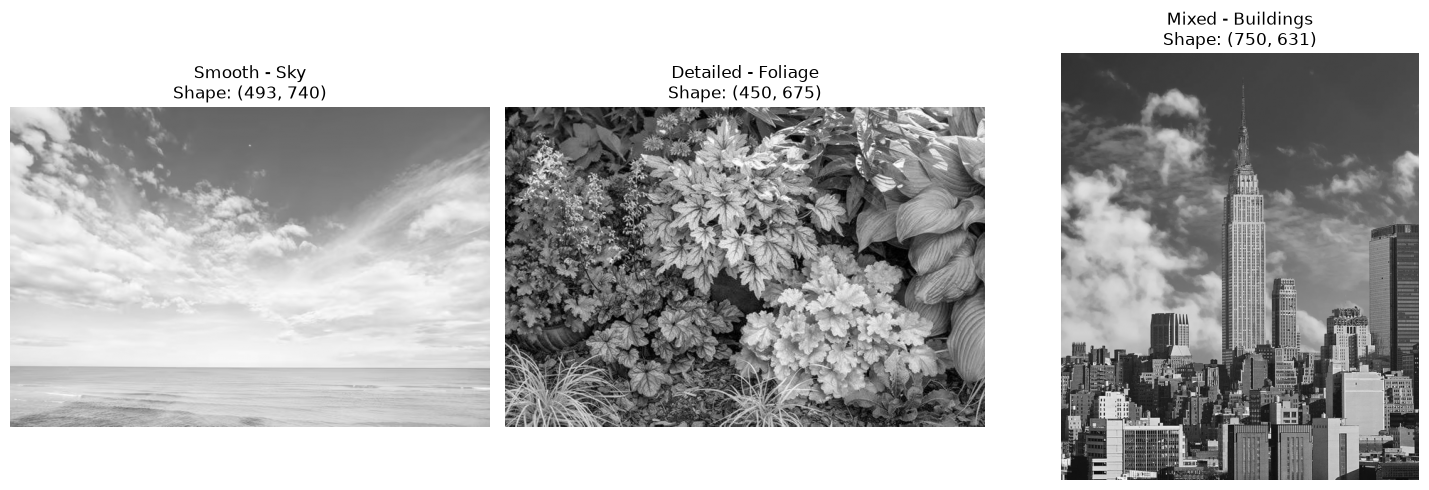

In [86]:
#Display the original image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, image) in zip(axes, images.items()):

    ax.imshow(image, cmap="gray", vmin=0, vmax=1)

    ax.set_title(
        f"{name}\nShape: {image.shape}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

The three images were selected to represent different levels of spatial complexity.

The sky image contains large areas where neighbouring pixels have similar intensity,
so I expect it to have substantial redundancy.

The foliage image contains many small edges, leaves and local intensity changes,
so I expect its information to be distributed across more SVD components.

The building image contains both relatively smooth surfaces and strong geometric
edges, so I expect its behaviour to fall between the other two images.

In [87]:
#Compute the SVD

svd_results = {}

for name, image in images.items():

    U, s, Vt = np.linalg.svd(
        image,
        full_matrices=False
    )

    svd_results[name] = {
        "U": U,
        "s": s,
        "Vt": Vt
    }

    print(name)
    print("U Shape: ", U.shape)
    print("Number of singular values: ", len(s))
    print("Vt Shape: ", Vt.shape)
    print()

Smooth - Sky
U Shape:  (493, 493)
Number of singular values:  493
Vt Shape:  (493, 740)

Detailed - Foliage
U Shape:  (450, 450)
Number of singular values:  450
Vt Shape:  (450, 675)

Mixed - Buildings
U Shape:  (750, 631)
Number of singular values:  631
Vt Shape:  (631, 631)



In [88]:
#Write the reconstruction function

def reconstruct_image(U, s, Vt, k):

    U_k = U[:, :k]

    s_k = s[:k]

    Vt_k = Vt[:k, :]

    reconstructed = U_k @ np.diag(s_k) @ Vt_k

    return reconstructed

In [89]:
#Full-rank verification

for name, image in images.items():

    U = svd_results[name]["U"]
    s = svd_results[name]["s"]
    Vt = svd_results[name]["Vt"]

    full_rank = len(s)

    reconstructed = reconstruct_image(
        U, s, Vt, full_rank
    )

    check = np.allclose(
        image,
        reconstructed
    )

    max_difference = np.max(
        np.abs(image - reconstructed)
    )

    print(name)
    print("Full-rank reconstruction correct:", check)
    print("Maximum difference:", max_difference)
    print()

Smooth - Sky
Full-rank reconstruction correct: True
Maximum difference: 3.0941915696303113e-13

Detailed - Foliage
Full-rank reconstruction correct: True
Maximum difference: 1.1507461650239748e-13

Mixed - Buildings
Full-rank reconstruction correct: True
Maximum difference: 5.53113110868253e-13



In [90]:
#Create the measurement function

def calculate_metrics(image, U, s, Vt, k):

    m, n = image.shape

    reconstructed = reconstruct_image(
        U, s, Vt, k
    )

    numbers_stored = k * (m + n + 1)

    compression_ratio = (
        (m * n) / numbers_stored
    )

    relative_error = (
        np.linalg.norm(image - reconstructed, ord="fro")
        / np.linalg.norm(image, ord="fro")
    )

    energy_retained = (
        np.sum(s[:k] ** 2)
        / np.sum(s ** 2)
    )

    return (
        numbers_stored,
        compression_ratio,
        relative_error,
        energy_retained
    )

In [91]:
#Calculate break-even k

def calculate_break_even(image):

    m, n = image.shape

    break_even = (
        (m * n) / (m + n + 1)
    )

    return break_even

In [92]:
for name, image in images.items():

    break_even = calculate_break_even(image)

    first_expanding_k = (
        int(np.floor(break_even)) + 1
    )

    print(name)
    print(
        "Break-even k:",
        round(break_even, 2)
    )
    print(
        "First integer k storing more than original:",
        first_expanding_k
    )
    print()

Smooth - Sky
Break-even k: 295.64
First integer k storing more than original: 296

Detailed - Foliage
Break-even k: 269.76
First integer k storing more than original: 270

Mixed - Buildings
Break-even k: 342.44
First integer k storing more than original: 343



In [93]:
#Choose reconstruction k values
base_k_values = [
    1,
    5,
    10,
    20,
    50,
    100
]

In [94]:
#Build the complete results table

results = []

for name, image in images.items():

    U = svd_results[name]["U"]
    s = svd_results[name]["s"]
    Vt = svd_results[name]["Vt"]

    full_rank = len(s)

    k_values = []

    for k in base_k_values:

        if k <= full_rank:
            k_values.append(k)

    k_values.append(full_rank)

    k_values = sorted(set(k_values))

    for k in k_values:

        stored, ratio, error, energy = calculate_metrics(
            image,
            U,
            s,
            Vt,
            k
        )

        results.append({
            "Image": name,
            "k": k,
            "Numbers Stored": stored,
            "Compression Ratio": ratio,
            "Relative Error": error,
            "Energy Retained": energy
        })

results_df = pd.DataFrame(results)

results_df

,Image,k,Numbers Stored,Compression Ratio,Relative Error,Energy Retained
0,Smooth - Sky,1,1234,295.640194,1.066646e-01,0.988623
1,Smooth - Sky,5,6170,59.128039,5.168444e-02,0.997329
2,Smooth - Sky,10,12340,29.564019,3.970220e-02,0.998424
3,Smooth - Sky,20,24680,14.782010,2.685022e-02,0.999279
4,Smooth - Sky,50,61700,5.912804,1.389552e-02,0.999807
5,Smooth - Sky,100,123400,2.956402,6.896365e-03,0.999952
6,Smooth - Sky,493,608362,0.599676,1.374236e-14,1.000000
7,Detailed - Foliage,1,1126,269.760213,4.016231e-01,0.838699
8,Detailed - Foliage,5,5630,53.952043,3.169892e-01,0.899518
9,Detailed - Foliage,10,11260,26.976021,2.778089e-01,0.922822


In [95]:
#Display a cleaner results table

display_results = results_df.copy()

display_results["Compression Ratio"] = (
    display_results["Compression Ratio"]
    .map(lambda x: f"{x:.2f}x")
)

display_results["Relative Error"] = (
    display_results["Relative Error"]
    .map(lambda x: f"{x:.4f}")
)

display_results["Energy Retained"] = (
    display_results["Energy Retained"]
    .map(lambda x: f"{100*x:.2f}%")
)

display_results

,Image,k,Numbers Stored,Compression Ratio,Relative Error,Energy Retained
0,Smooth - Sky,1,1234,295.64x,0.1067,98.86%
1,Smooth - Sky,5,6170,59.13x,0.0517,99.73%
2,Smooth - Sky,10,12340,29.56x,0.0397,99.84%
3,Smooth - Sky,20,24680,14.78x,0.0269,99.93%
4,Smooth - Sky,50,61700,5.91x,0.0139,99.98%
5,Smooth - Sky,100,123400,2.96x,0.0069,100.00%
6,Smooth - Sky,493,608362,0.60x,0.0000,100.00%
7,Detailed - Foliage,1,1126,269.76x,0.4016,83.87%
8,Detailed - Foliage,5,5630,53.95x,0.3170,89.95%
9,Detailed - Foliage,10,11260,26.98x,0.2778,92.28%


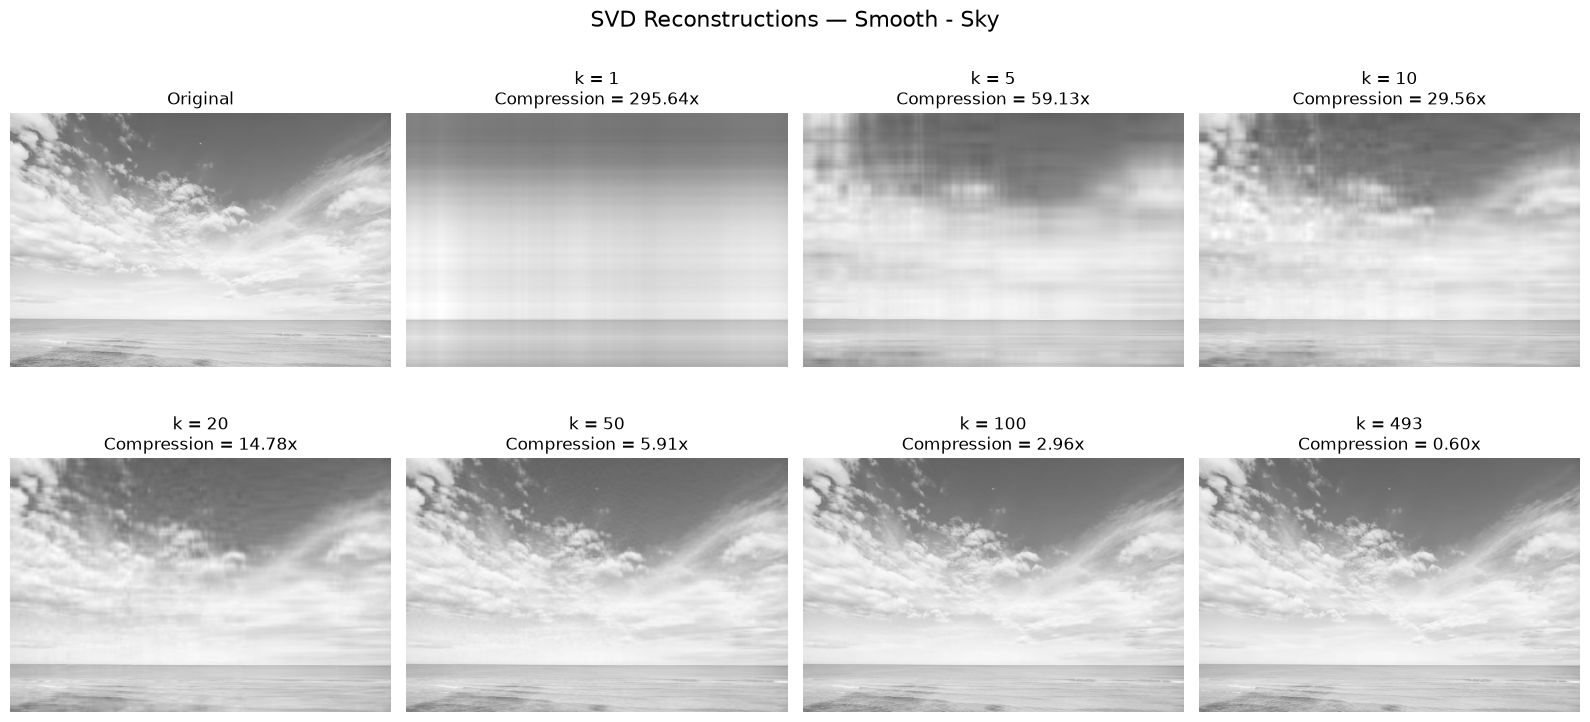

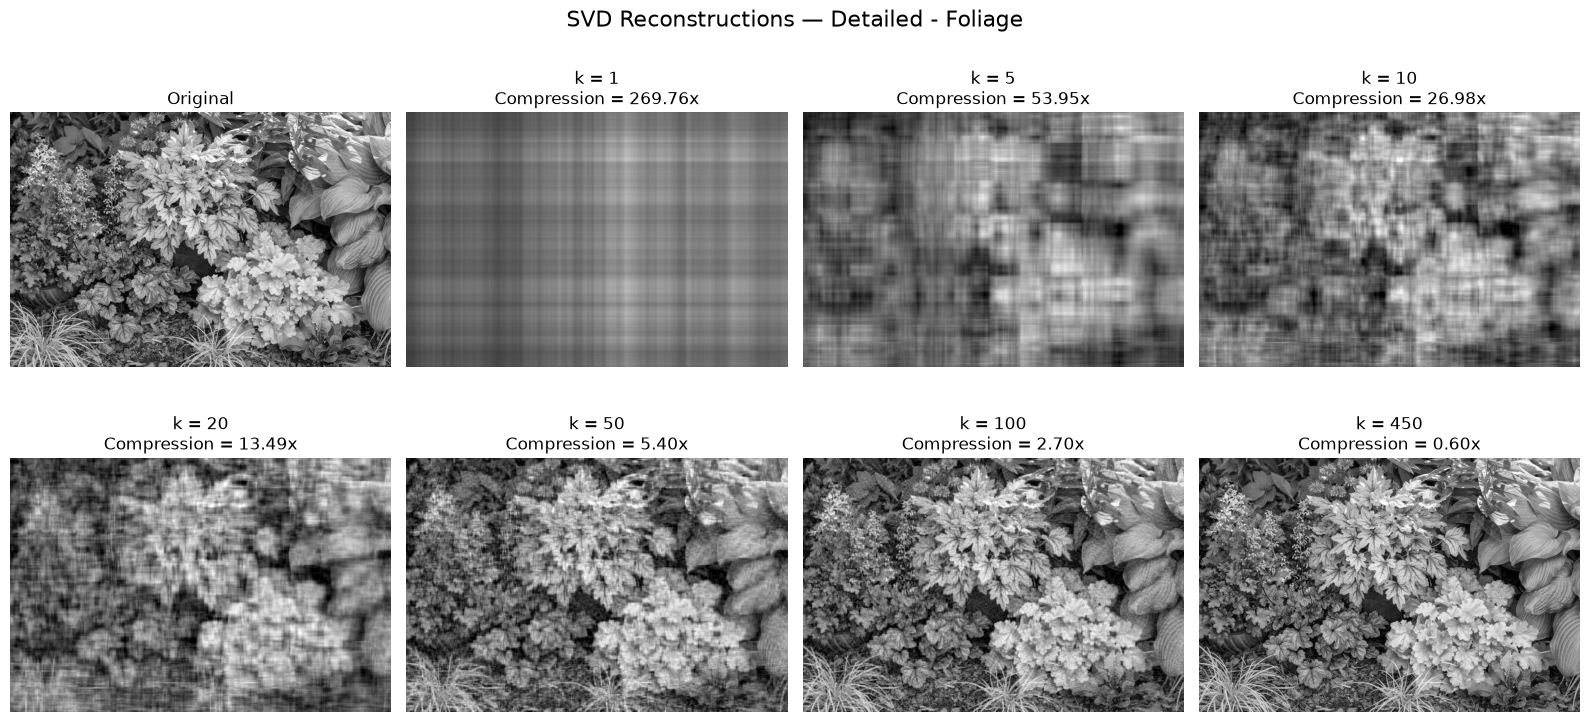

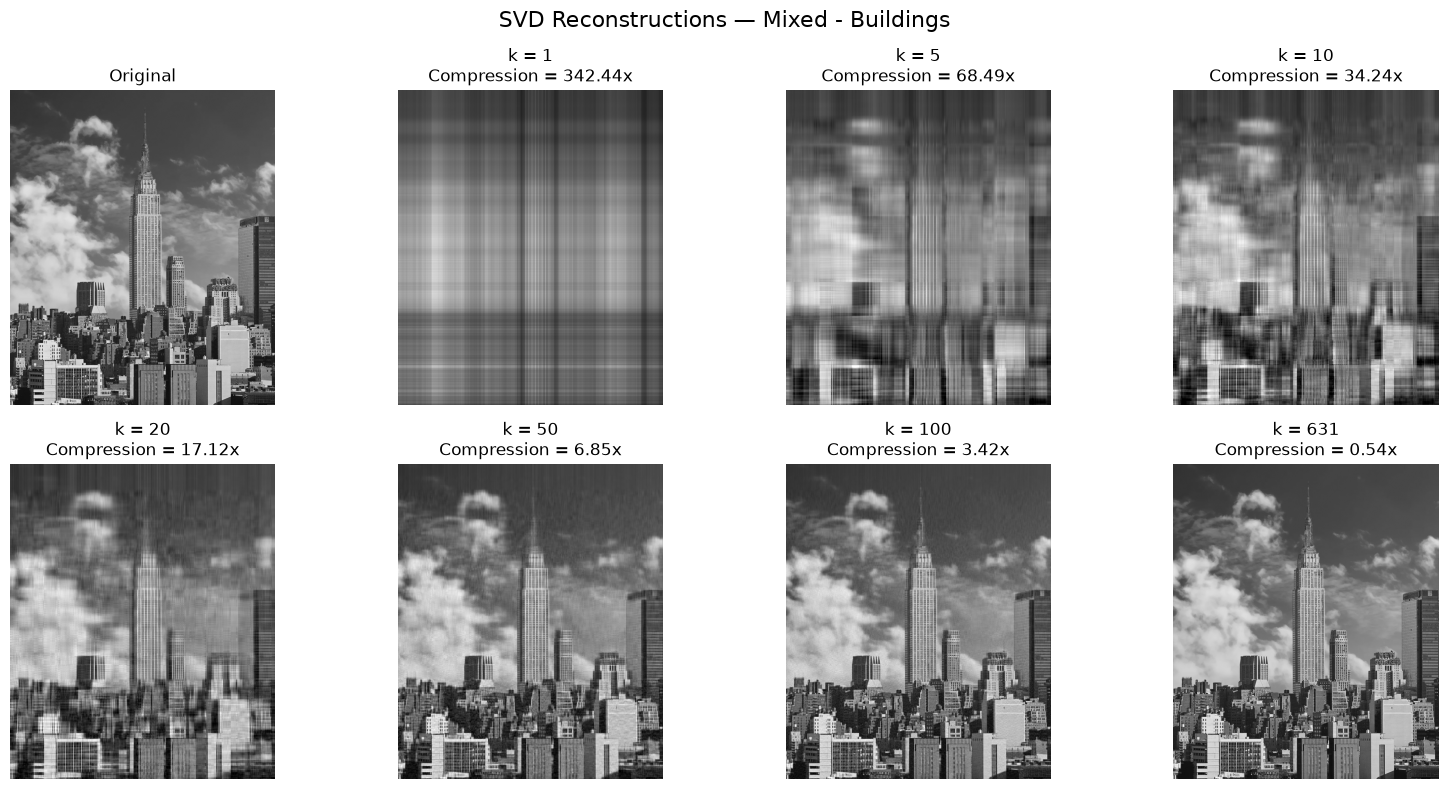

In [96]:
#Reconstruction grids

for name, image in images.items():

    U = svd_results[name]["U"]
    s = svd_results[name]["s"]
    Vt = svd_results[name]["Vt"]

    full_rank = len(s)

    k_values = [
        k for k in base_k_values
        if k <= full_rank
    ]

    k_values.append(full_rank)
    k_values = sorted(set(k_values))

    total_plots = len(k_values) + 1

    columns = 4
    rows = int(np.ceil(total_plots / columns))

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(16, 4 * rows)
    )

    axes = np.array(axes).reshape(-1)

    axes[0].imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[0].set_title("Original")
    axes[0].axis("off")

    for index, k in enumerate(
        k_values,
        start=1
    ):

        reconstructed = reconstruct_image(
            U,
            s,
            Vt,
            k
        )

        reconstructed_display = np.clip(
            reconstructed,
            0,
            1
        )

        stored, ratio, error, energy = calculate_metrics(
            image,
            U,
            s,
            Vt,
            k
        )

        axes[index].imshow(
            reconstructed_display,
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[index].set_title(
            f"k = {k}\n"
            f"Compression = {ratio:.2f}x"
        )

        axes[index].axis("off")

    for index in range(
        total_plots,
        len(axes)
    ):
        axes[index].axis("off")

    plt.suptitle(
        f"SVD Reconstructions — {name}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

In [97]:
#Cumulative energy function

def cumulative_energy(s):

    energy = np.cumsum(s ** 2)

    total_energy = np.sum(s ** 2)

    return energy / total_energy

In [98]:
#Find k for energy thresholds

def k_for_energy(s, threshold):

    energy = cumulative_energy(s)

    k = (
        np.searchsorted(
            energy,
            threshold
        )
        + 1
    )

    return k

In [99]:
#Calculate all energy thresholds

energy_results = []

for name in images:

    s = svd_results[name]["s"]

    k_90 = k_for_energy(s, 0.90)
    k_99 = k_for_energy(s, 0.99)
    k_999 = k_for_energy(s, 0.999)

    energy_results.append({
        "Image": name,
        "k for 90%": k_90,
        "k for 99%": k_99,
        "k for 99.9%": k_999
    })

energy_df = pd.DataFrame(
    energy_results
)

energy_df

,Image,k for 90%,k for 99%,k for 99.9%
0,Smooth - Sky,1,2,16
1,Detailed - Foliage,6,112,260
2,Mixed - Buildings,2,51,205


In [100]:
#Find k for relative error below 5%

def k_for_error_target(s, target=0.05):

    energy = cumulative_energy(s)

    errors = np.sqrt(
        np.maximum(
            0,
            1 - energy
        )
    )

    matching = np.where(
        errors < target
    )[0]

    if len(matching) == 0:
        return None

    return matching[0] + 1

In [101]:
#Calculate the 5% error criterion

for name in images:

    s = svd_results[name]["s"]

    k_error = k_for_error_target(
        s,
        target=0.05
    )

    print(
        name,
        "-> smallest k with error < 5%:",
        k_error
    )

Smooth - Sky -> smallest k with error < 5%: 6
Detailed - Foliage -> smallest k with error < 5%: 206
Mixed - Buildings -> smallest k with error < 5%: 138


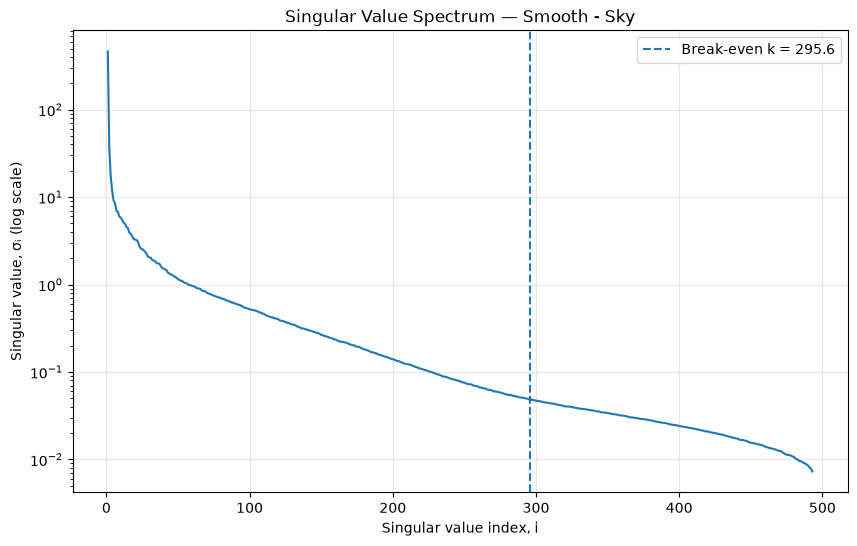

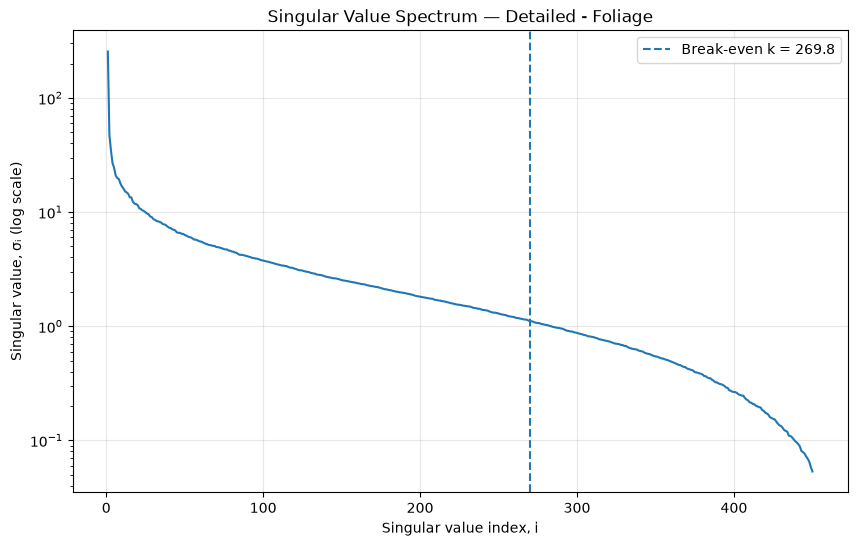

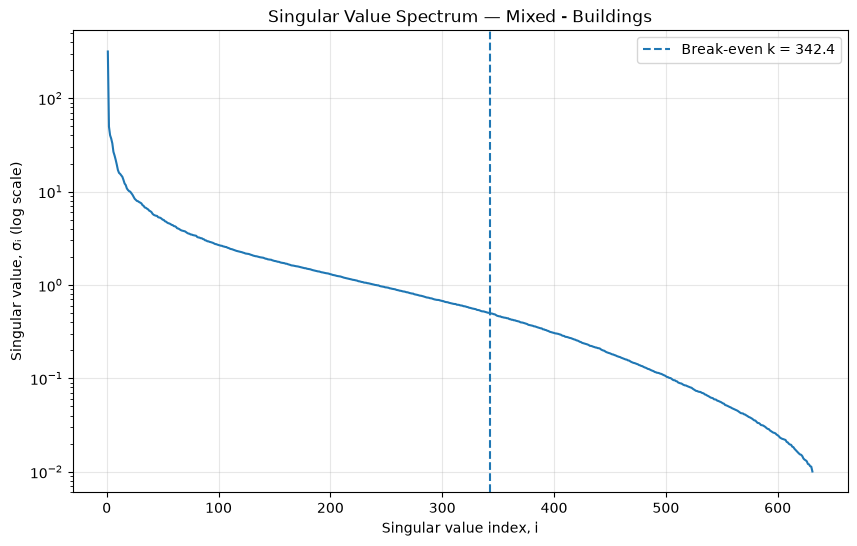

In [102]:
#Plot the singular-value spectrum

for name, image in images.items():

    s = svd_results[name]["s"]

    break_even = calculate_break_even(
        image
    )

    x = np.arange(
        1,
        len(s) + 1
    )

    plt.figure(figsize=(10, 6))

    plt.semilogy(
        x,
        s
    )

    plt.axvline(
        break_even,
        linestyle="--",
        label=f"Break-even k = {break_even:.1f}"
    )

    plt.xlabel(
        "Singular value index, i"
    )

    plt.ylabel(
        "Singular value, σᵢ (log scale)"
    )

    plt.title(
        f"Singular Value Spectrum — {name}"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [103]:
#Implement the elbow method

def find_elbow(s):

    x = np.arange(
        1,
        len(s) + 1
    )

    y = np.log10(
        s + 1e-12
    )

    best_k = None
    best_error = np.inf

    for split in range(
        5,
        len(s) - 5
    ):

        first_line = np.polyfit(
            x[:split],
            y[:split],
            1
        )

        second_line = np.polyfit(
            x[split:],
            y[split:],
            1
        )

        first_prediction = np.polyval(
            first_line,
            x[:split]
        )

        second_prediction = np.polyval(
            second_line,
            x[split:]
        )

        first_error = np.sum(
            (
                y[:split]
                - first_prediction
            ) ** 2
        )

        second_error = np.sum(
            (
                y[split:]
                - second_prediction
            ) ** 2
        )

        total_error = (
            first_error
            + second_error
        )

        if total_error < best_error:

            best_error = total_error

            best_k = split

    return best_k

In [ ]:
#Calculate elbow k

for name in images:

    s = svd_results[name]["s"]

    elbow_k = find_elbow(s)

    print(
        name,
        "-> elbow k:",
        elbow_k
    )

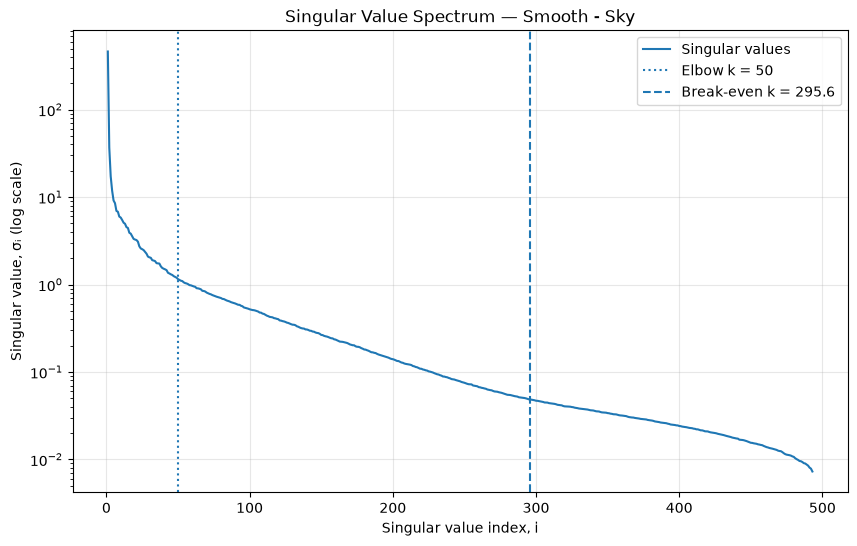

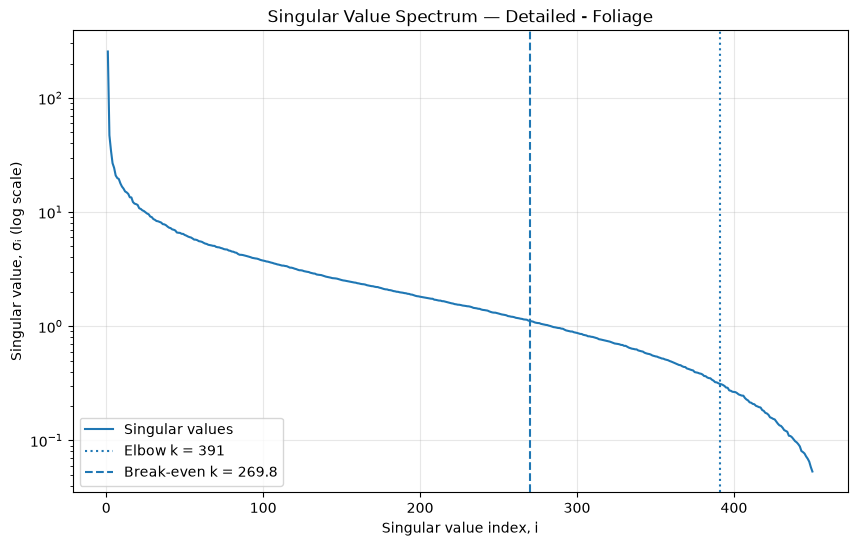

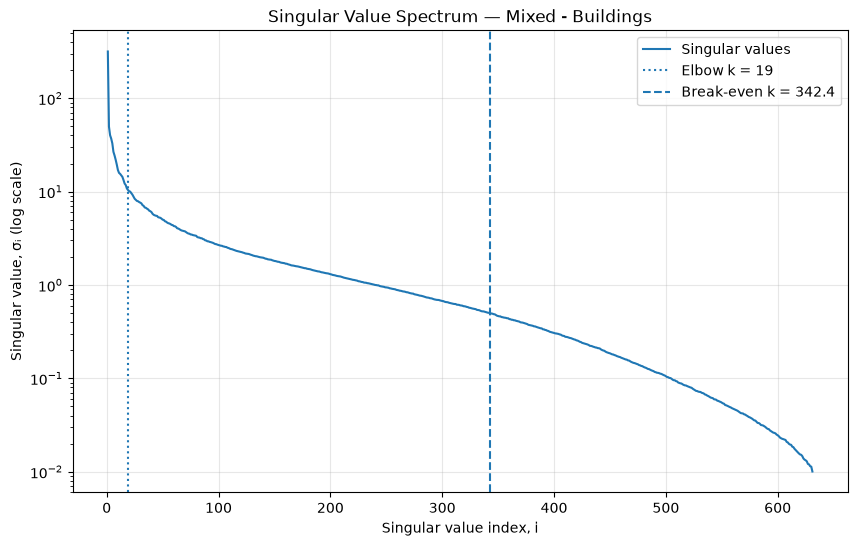

In [105]:
#Plot the elbow

for name, image in images.items():

    s = svd_results[name]["s"]

    break_even = calculate_break_even(
        image
    )

    elbow_k = find_elbow(s)

    x = np.arange(
        1,
        len(s) + 1
    )

    plt.figure(figsize=(10, 6))

    plt.semilogy(
        x,
        s,
        label="Singular values"
    )

    plt.axvline(
        elbow_k,
        linestyle=":",
        label=f"Elbow k = {elbow_k}"
    )

    plt.axvline(
        break_even,
        linestyle="--",
        label=f"Break-even k = {break_even:.1f}"
    )

    plt.xlabel(
        "Singular value index, i"
    )

    plt.ylabel(
        "Singular value, σᵢ (log scale)"
    )

    plt.title(
        f"Singular Value Spectrum — {name}"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [106]:
#Summary

summary = []

for name, image in images.items():

    s = svd_results[name]["s"]

    m, n = image.shape

    break_even = calculate_break_even(
        image
    )

    k_90 = k_for_energy(
        s,
        0.90
    )

    k_99 = k_for_energy(
        s,
        0.99
    )

    k_999 = k_for_energy(
        s,
        0.999
    )

    elbow_k = find_elbow(s)

    k_error = k_for_error_target(
        s,
        0.05
    )

    compression_at_error = (
        (m * n)
        /
        (
            k_error
            * (m + n + 1)
        )
    )

    summary.append({
        "Image": name,
        "Break-even k": break_even,
        "k @ 90% energy": k_90,
        "k @ 99% energy": k_99,
        "k @ 99.9% energy": k_999,
        "Elbow k": elbow_k,
        "k @ error < 5%": k_error,
        "Compression @ 5% error": compression_at_error
    })

summary_df = pd.DataFrame(summary)

summary_df.round(2)

,Image,Break-even k,k @ 90% energy,k @ 99% energy,k @ 99.9% energy,Elbow k,k @ error < 5%,Compression @ 5% error
0,Smooth - Sky,295.64,1,2,16,50,6,49.27
1,Detailed - Foliage,269.76,6,112,260,391,206,1.31
2,Mixed - Buildings,342.44,2,51,205,19,138,2.48


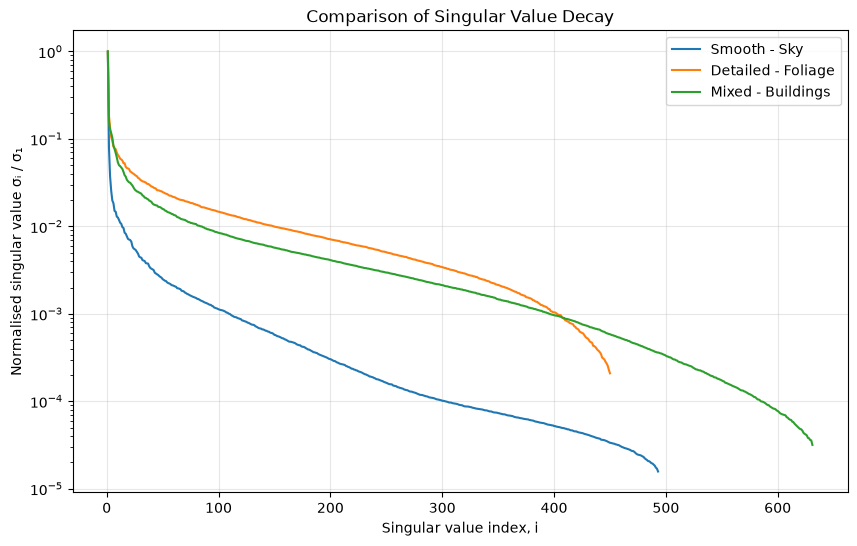

In [107]:
#Compare the spectra directly

plt.figure(figsize=(10, 6))

for name in images:

    s = svd_results[name]["s"]

    normalised_s = (
        s / s[0]
    )

    x = np.arange(
        1,
        len(s) + 1
    )

    plt.semilogy(
        x,
        normalised_s,
        label=name
    )

plt.xlabel(
    "Singular value index, i"
)

plt.ylabel(
    "Normalised singular value σᵢ / σ₁"
)

plt.title(
    "Comparison of Singular Value Decay"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [108]:
#Investigate the strange behaviour of energy

centered_svd_results = {}

for name, image in images.items():

    mean_brightness = np.mean(
        image
    )

    centered_image = (
        image - mean_brightness
    )

    U_c, s_c, Vt_c = np.linalg.svd(
        centered_image,
        full_matrices=False
    )

    centered_svd_results[name] = {
        "s": s_c
    }

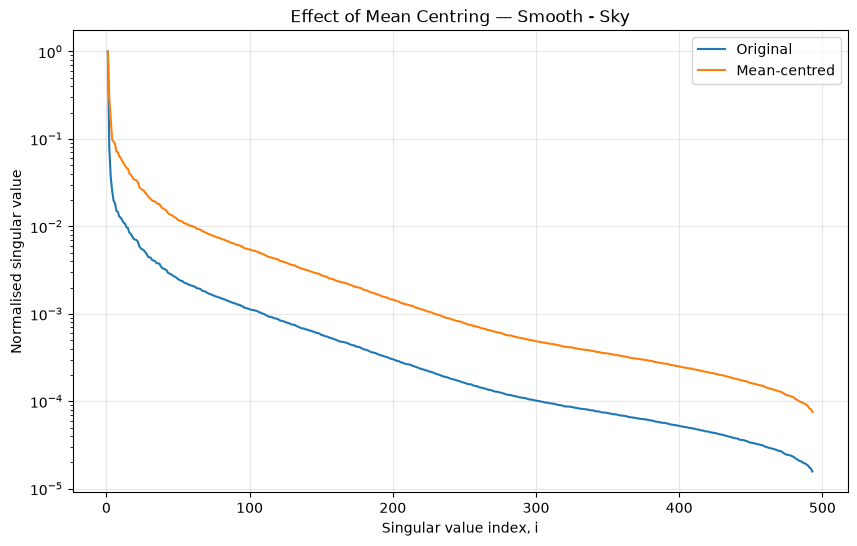

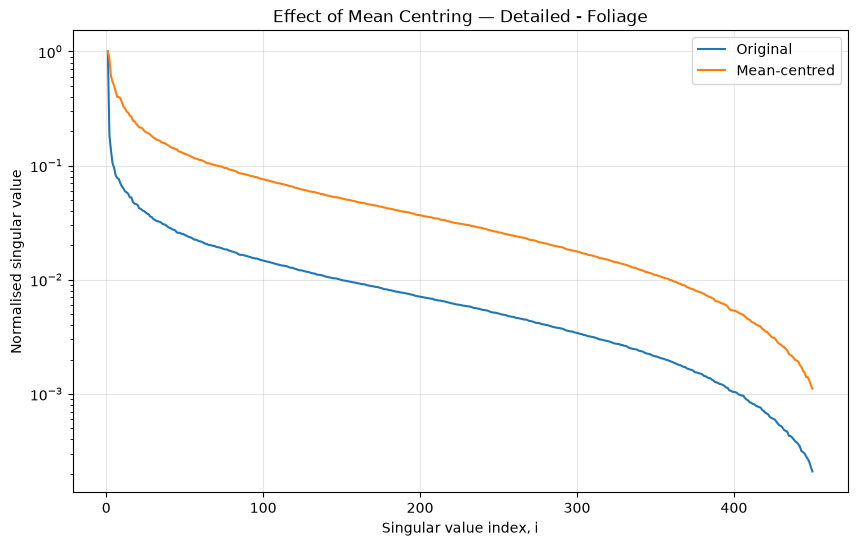

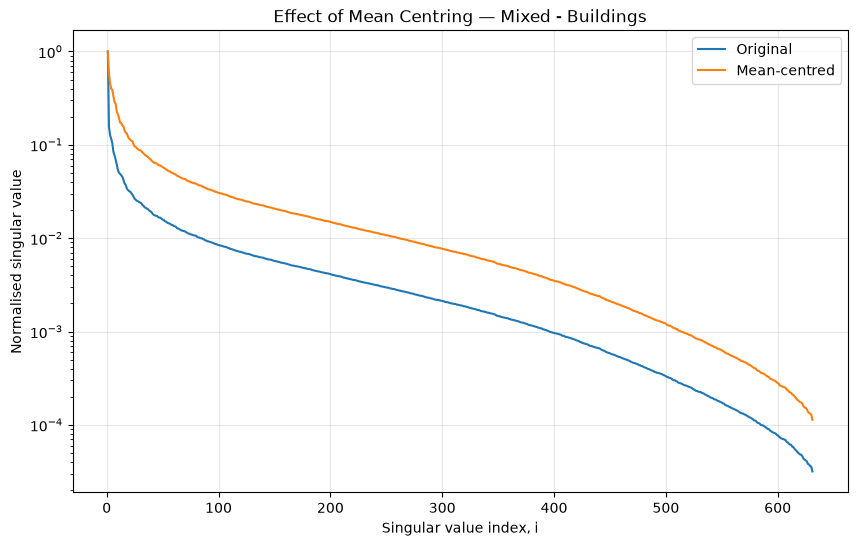

In [109]:
#Compare centred and uncentred spectra

for name in images:

    original_s = (
        svd_results[name]["s"]
    )

    centered_s = (
        centered_svd_results[name]["s"]
    )

    x = np.arange(
        1,
        len(original_s) + 1
    )

    plt.figure(figsize=(10, 6))

    plt.semilogy(
        x,
        original_s / original_s[0],
        label="Original"
    )

    plt.semilogy(
        x,
        centered_s / centered_s[0],
        label="Mean-centred"
    )

    plt.xlabel(
        "Singular value index, i"
    )

    plt.ylabel(
        "Normalised singular value"
    )

    plt.title(
        f"Effect of Mean Centring — {name}"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [110]:
#Gaussian noise experiment

smooth_image = images[
    "Smooth - Sky"
]

low_noise_level = 0.02
high_noise_level = 0.08

In [111]:
#Add noise
low_noise = rng.normal(
    0,
    low_noise_level,
    smooth_image.shape
)

high_noise = rng.normal(
    0,
    high_noise_level,
    smooth_image.shape
)

smooth_low_noise = np.clip(
    smooth_image + low_noise,
    0,
    1
)

smooth_high_noise = np.clip(
    smooth_image + high_noise,
    0,
    1
)

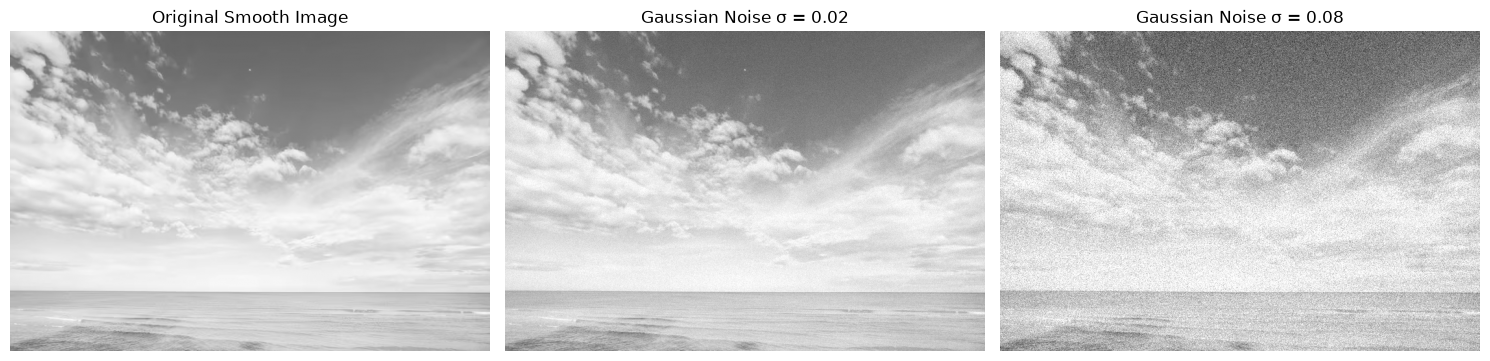

In [112]:
#Display the noise experiment

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    smooth_image,
    cmap="gray",
    vmin=0,
    vmax=1
)

axes[0].set_title(
    "Original Smooth Image"
)

axes[1].imshow(
    smooth_low_noise,
    cmap="gray",
    vmin=0,
    vmax=1
)

axes[1].set_title(
    f"Gaussian Noise σ = {low_noise_level}"
)

axes[2].imshow(
    smooth_high_noise,
    cmap="gray",
    vmin=0,
    vmax=1
)

axes[2].set_title(
    f"Gaussian Noise σ = {high_noise_level}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [116]:
#compute noisy spectra
_, s_clean, _ = np.linalg.svd(
    smooth_image,
    full_matrices=False
)

_, s_low, _ = np.linalg.svd(
    smooth_low_noise,
    full_matrices=False
)

_, s_high, _ = np.linalg.svd(
    smooth_high_noise,
    full_matrices=False
)

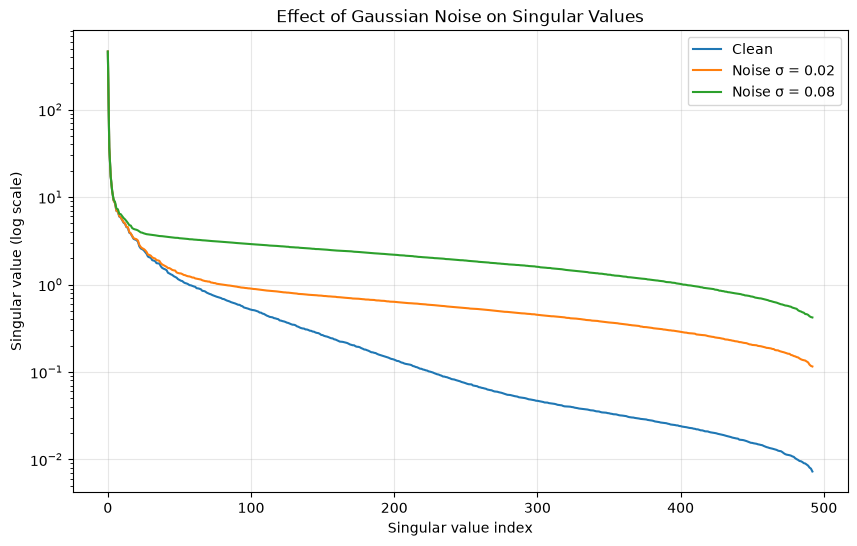

In [118]:
#Plot noisy spectra

plt.figure(figsize=(10, 6))

plt.semilogy(
    s_clean,
    label="Clean"
)

plt.semilogy(
    s_low,
    label=f"Noise σ = {low_noise_level}"
)

plt.semilogy(
    s_high,
    label=f"Noise σ = {high_noise_level}"
)

plt.xlabel(
    "Singular value index"
)

plt.ylabel(
    "Singular value (log scale)"
)

plt.title(
    "Effect of Gaussian Noise on Singular Values"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [119]:
#Demonstrate denoising

U_noise, s_noise, Vt_noise = np.linalg.svd(
    smooth_high_noise,
    full_matrices=False
)

denoise_k_values = [
    5,
    10,
    20,
    40,
    80
]

denoise_k_values = [
    k for k in denoise_k_values
    if k <= len(s_noise)
]

In [120]:
#Compare

denoise_results = []

for k in denoise_k_values:

    denoised = reconstruct_image(
        U_noise,
        s_noise,
        Vt_noise,
        k
    )

    error_to_clean = (
        np.linalg.norm(
            smooth_image - denoised,
            ord="fro"
        )
        /
        np.linalg.norm(
            smooth_image,
            ord="fro"
        )
    )

    denoise_results.append({
        "k": k,
        "Error compared with clean image": error_to_clean
    })

denoise_df = pd.DataFrame(
    denoise_results
)

denoise_df

,k,Error compared with clean image
0,5,0.053616
1,10,0.044502
2,20,0.039687
3,40,0.048062
4,80,0.063227


In [121]:
#Compare the noisy image itself to the clean image

noisy_error = (
    np.linalg.norm(
        smooth_image
        - smooth_high_noise,
        ord="fro"
    )
    /
    np.linalg.norm(
        smooth_image,
        ord="fro"
    )
)

print(
    "Relative error of noisy image:",
    noisy_error
)

Relative error of noisy image: 0.09960037264483446


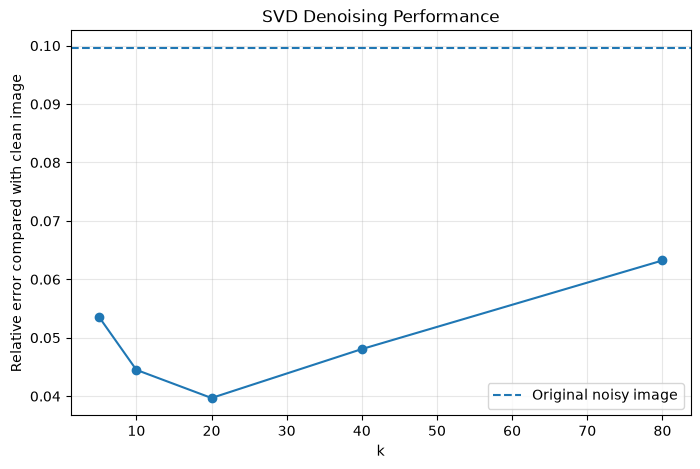

In [122]:
#Plot error vs k
plt.figure(figsize=(8, 5))

plt.plot(
    denoise_df["k"],
    denoise_df[
        "Error compared with clean image"
    ],
    marker="o"
)

plt.axhline(
    noisy_error,
    linestyle="--",
    label="Original noisy image"
)

plt.xlabel("k")
plt.ylabel(
    "Relative error compared with clean image"
)

plt.title(
    "SVD Denoising Performance"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [123]:
#Calculate SSIM

from skimage.metrics import structural_similarity

ssim_results = []

for name, image in images.items():

    U = svd_results[name]["U"]
    s = svd_results[name]["s"]
    Vt = svd_results[name]["Vt"]

    k = k_for_error_target(
        s,
        0.05
    )

    reconstructed = reconstruct_image(
        U,
        s,
        Vt,
        k
    )

    reconstructed = np.clip(
        reconstructed,
        0,
        1
    )

    ssim_value = structural_similarity(
        image,
        reconstructed,
        data_range=1.0
    )

    ssim_results.append({
        "Image": name,
        "k": k,
        "SSIM": ssim_value
    })

ssim_df = pd.DataFrame(
    ssim_results
)

ssim_df

,Image,k,SSIM
0,Smooth - Sky,6,0.813036
1,Detailed - Foliage,206,0.955523
2,Mixed - Buildings,138,0.912380
